In [ ]:
%load_ext autoreload
%autoreload 2
import os, sys

import sys
sys.path.append("../../")

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import h5py

import utils

from src.fmcw_simulation.simulation import FmcwRadar
from src.py_network.adaptive_resonate import AdaptiveResonate

plt.rc('xtick',labelsize=35)
plt.rc('ytick',labelsize=35)
mpl.rcParams['figure.figsize'] = (12, 7) 
mpl.rcParams['axes.titlesize'] = 40
mpl.rcParams['axes.labelsize'] =35
mpl.rcParams['legend.fontsize'] = 30
plt.rcParams['lines.linewidth'] = 3.0
plt.rcParams['text.usetex'] = False
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["#6ba0a6", "#d8584e", "#c09651", "#f8c08a", "#8e4f39", "#2f3240"])

In [ ]:
f = h5py.File('../../data/delft_moving_targets/fixed_dataset/radar_cube_single_channel_long.h5', 'r')
real = f['real']
imag = f['imag']

frame0 = np.array(real) + 1j * np.array(imag)
data_full = frame0

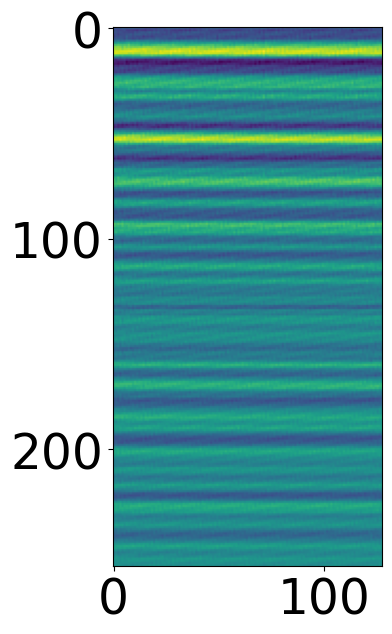

In [ ]:
mat= frame0[0]
c = plt.imshow(mat[:, :].real.T)

In [ ]:
class Param:
    pass

Param.n_frames    = 47
Param.ntt_range   = 256
Param.ntt_azimuth = 128
Param.Nt_a        = 1
Param.Nr_a        = 1
Param.Nt_e        = 1
Param.Nr_e        = 1
Param.Idel_time   = 5e-6
Param.ramp_start  = 10e-6
Param.ramp_end    = 70e-6
Param.T           = (Param.ramp_end + Param.Idel_time) * 12
Param.mu          = 30
Param.PRF         = 1 / (Param.T)
Param.Periodicity = (Param.T) * 12 * Param.ntt_azimuth
Param.fs          = 0.6e7
Param.Ts          = 1 / Param.fs
Param.T_d         = Param.ntt_range * Param.Ts
Param.B           = Param.mu * Param.T_d * 1e12
Param.c           = 3e8
Param.resolution  = Param.c / 2 / Param.B
Param.f0          = 78.5e9
Param.fc          = Param.f0 + Param.B/2
Param.lambda_     = Param.c / Param.fc
Param.dr          = Param.lambda_ / 2
Param.tm          = Param.T_d
Param.Ne          = 6
Param.Na          = 86
Param.T_sweep = Param.ramp_end - Param.ramp_start
Param.snr = 20

In [ ]:
data_full = data_full - np.mean(data_full, axis=1)[:, None, :]

In [ ]:
data = data_full.reshape((Param.ntt_azimuth * data_full.shape[0], Param.ntt_range))

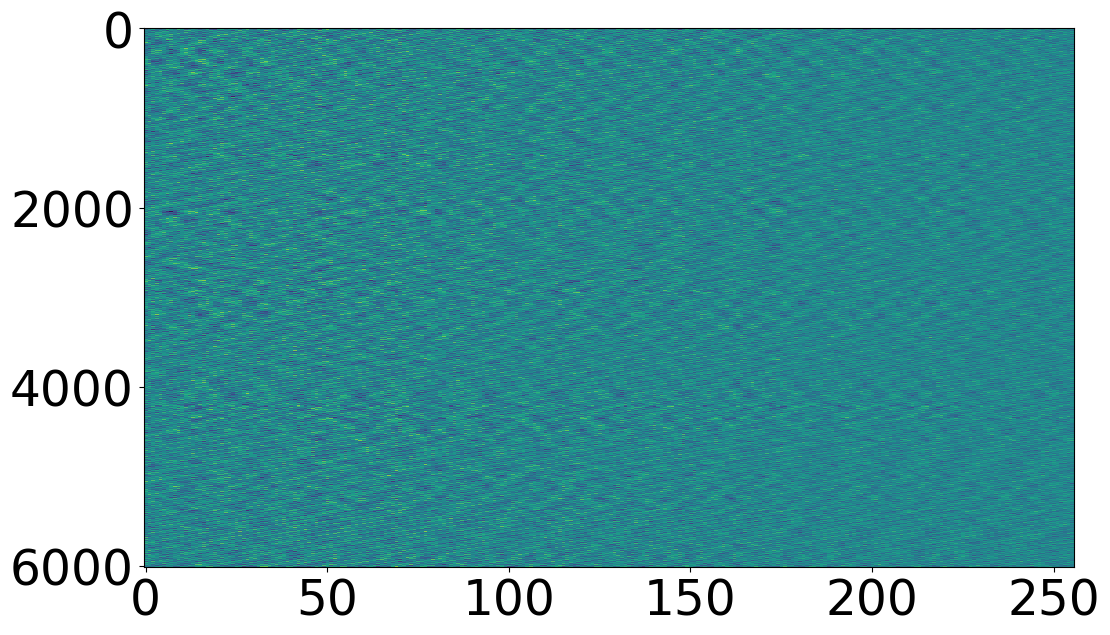

In [ ]:
plt.imshow(np.real(data[:, :]), interpolation="none", aspect="auto")

In [ ]:
radar_config = {
    "n_rx": 1,
    "fb" : Param.f0,
    "B" : Param.B,
    "n_chirps": Param.ntt_azimuth,
    "n_samples": Param.ntt_range,
    "t_chirp": Param.T_sweep,
    "IQ": True,
    "noise_std": 0.0001
}
fmcw = FmcwRadar(radar_config)

In [ ]:
def apply_hann(frame):

    new_frame = np.zeros_like(frame)

    hann_w = np.hanning(frame.shape[1])[None, :]

    # remove DC per chirp
    # frame = frame - frame.mean(axis=2, keepdims=True)

    # apply window
    new_frame = frame * hann_w

    return new_frame
        

In [ ]:
data = apply_hann(data * 1e-2)
# data *= 1e-2

/home/chistefano/code/tue/frequency_adaptive_clean/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/chistefano/code/tue/frequency_adaptive_clean/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


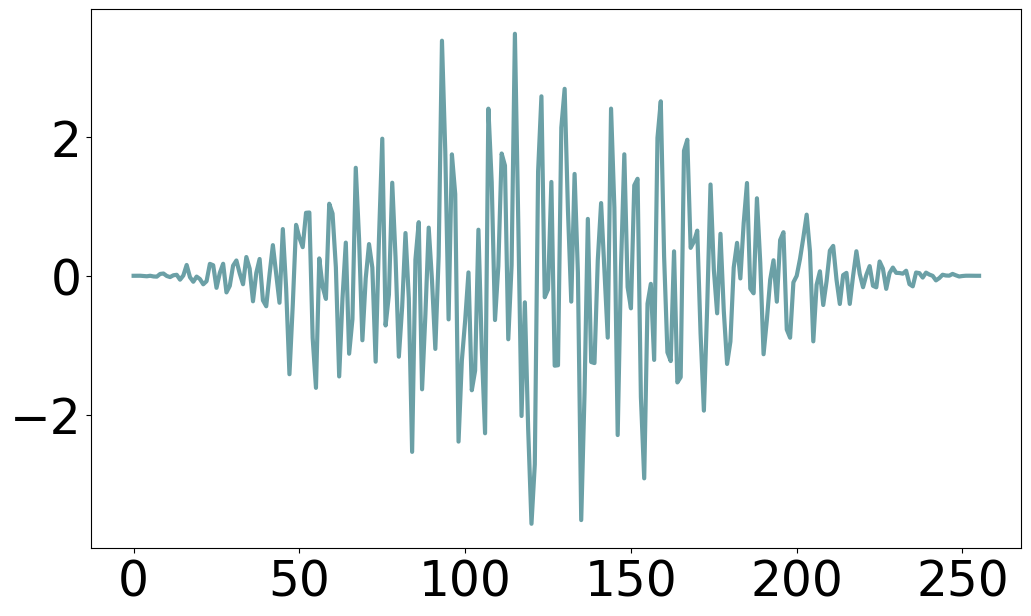

In [ ]:
plt.plot(data[0])

In [ ]:
n_units_range = 5
t_max = fmcw.t_chirp * fmcw.n_chirps * 1
res_net = AdaptiveResonate(
            n_units_range, 
            t_max, 
            (fmcw.t_chirp*1) / fmcw.n_samples, 
            k=1,
            feedback=True,
            w_scale= np.ones((fmcw.n_rx, n_units_range))*fmcw.t_chirp*100*0.2,
            n_rxs=fmcw.n_rx
)

# res_net.spike_condition = res_net.period_spiking
res_net.normalize_input = False
res_net.normalize_neuron = True
res_net.alpha_lpf = 1.0

res_net.spike_threshold = fmcw.get_freq_from_range(0.1)

res_net.wdot_mode = False

max_starting_freq = fmcw.get_freq_from_range(fmcw.get_ranges2().max() - 1e-2) * 2 * np.pi

# res_net.set_starting_frequency(
#             np.random.rand(res_net.n_rxs, res_net.nfreq) * (max_starting_freq) * 2 * np.pi
#         )

res_net.set_starting_frequency(
            np.linspace(10000, max_starting_freq, res_net.nfreq)
        )

In [ ]:
np_fft = np.abs(np.fft.fft(data_full[0, :, :], axis=1)).sum(axis=0)
# np_fft = np.abs(np.fft.fft(data_full[0, 0, :]))


In [ ]:
targets_fft = np.argsort(np_fft)[-n_units_range:]
targets_fft_meters = fmcw.get_ranges2()[targets_fft]

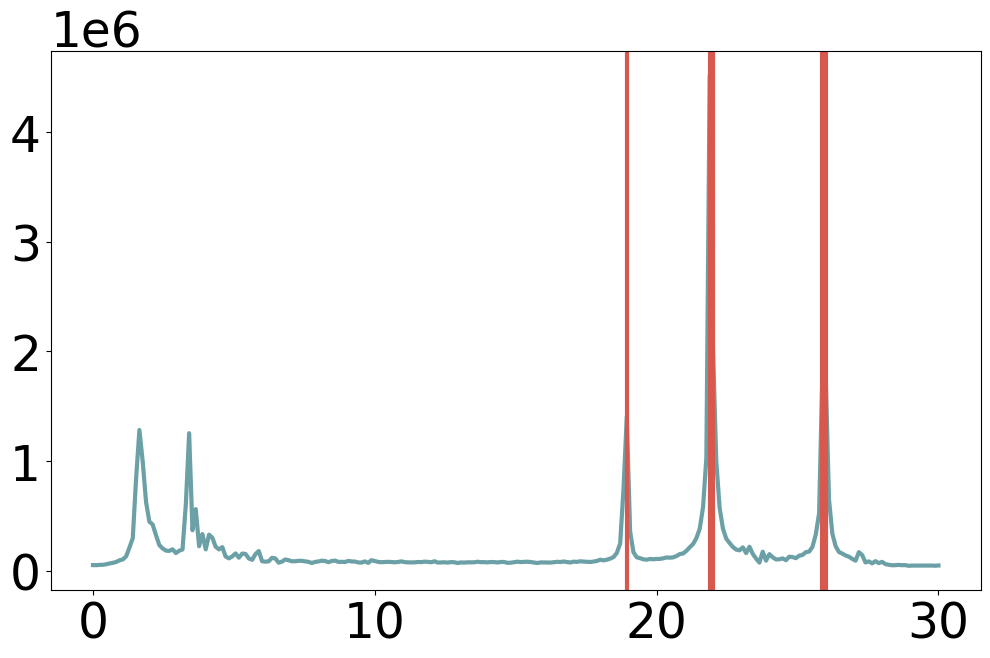

In [ ]:

plt.plot(fmcw.get_ranges2(), np.abs(np_fft))
for i in range(targets_fft_meters.size):
    plt.axvline(targets_fft_meters[i], c="C1")

In [ ]:
input_signal = data.reshape((1, -1))

In [ ]:
input_signal_size = input_signal.size
signal1 = input_signal[:, :input_signal_size // 10]
signal2 = input_signal[:, input_signal_size // 10:]

# run simulation
vs_hist_range, ws_hist = res_net.update_neurons_c(input_signal)

In [ ]:
range_hist = fmcw.get_range_from_freq(ws_hist / (2*np.pi))

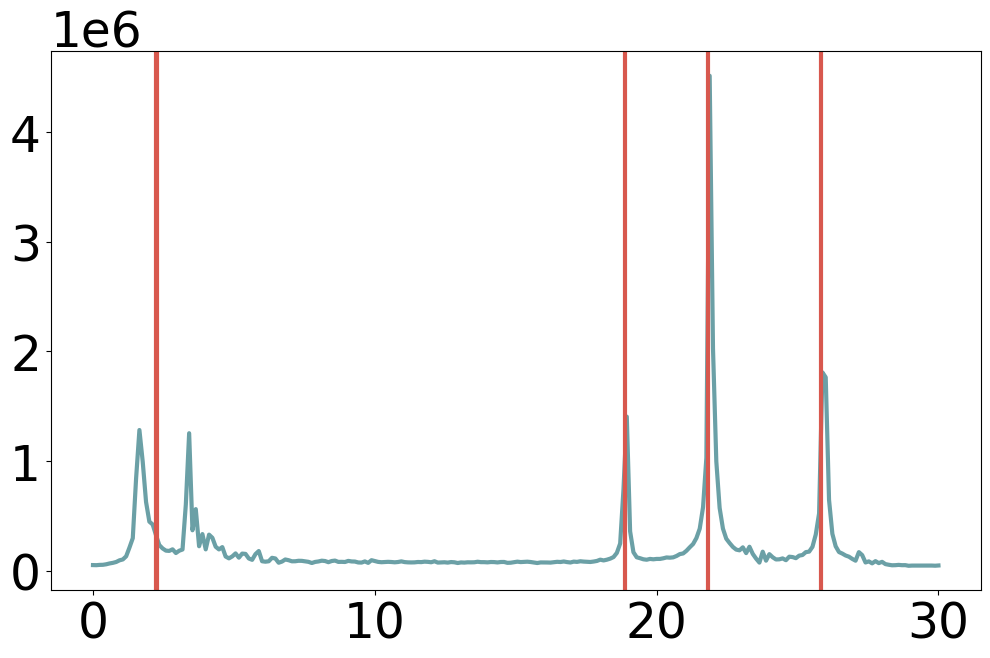

In [ ]:

plt.plot(fmcw.get_ranges2(), np.abs(np_fft))
for i in range(range_hist[-1].size):
    plt.axvline(range_hist[-1, 0, i], c="C1")

In [ ]:
vs_hist_frame = vs_hist_range.reshape((fmcw.n_chirps*data_full.shape[0], fmcw.n_samples, n_units_range))

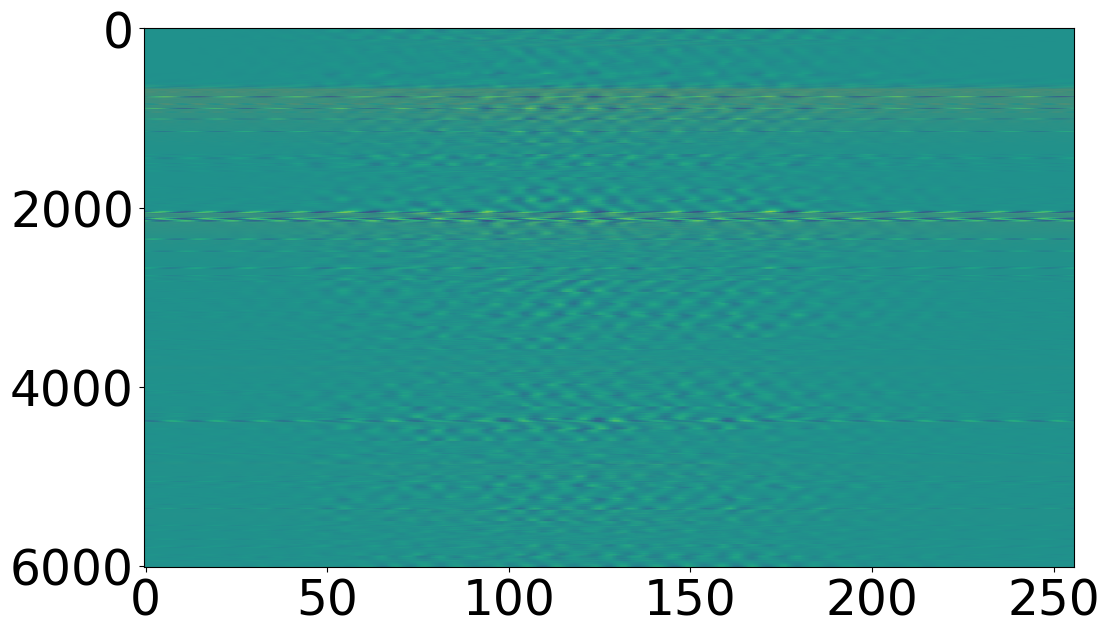

In [ ]:
plt.imshow(vs_hist_frame[:, :, 0].real, aspect='auto')

In [ ]:
doppler_signal = vs_hist_frame[:, fmcw.n_samples // 2, :].reshape((-1, fmcw.n_chirps, n_units_range))

In [ ]:
for i in range(n_units_range):    
    doppler_signal[:, :, i] = apply_hann(doppler_signal[:, :, i])

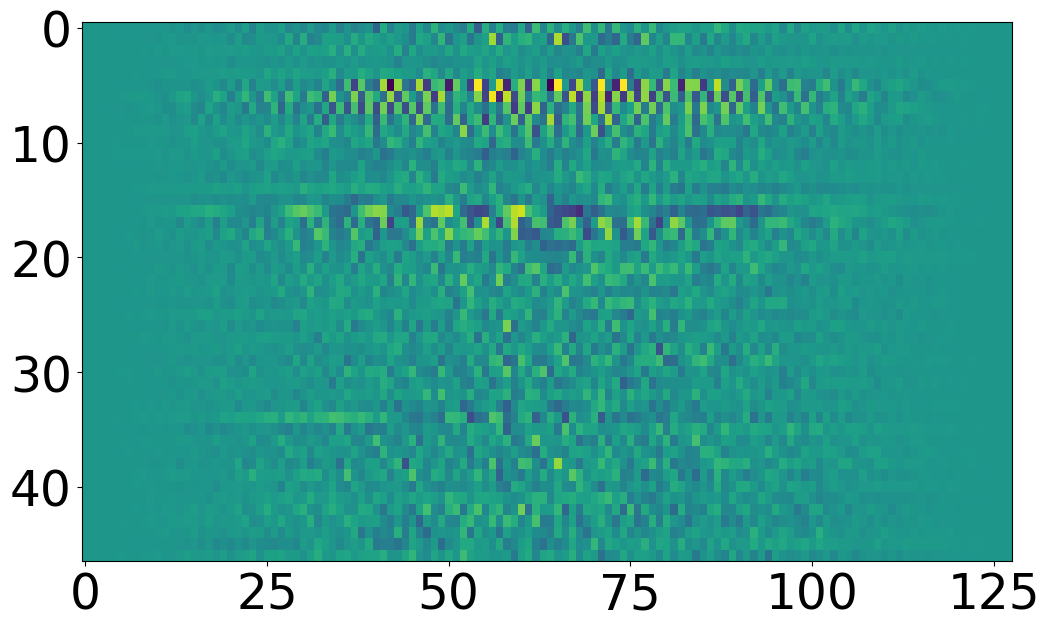

In [ ]:
plt.imshow(doppler_signal[:, :, 0].real, aspect='auto')

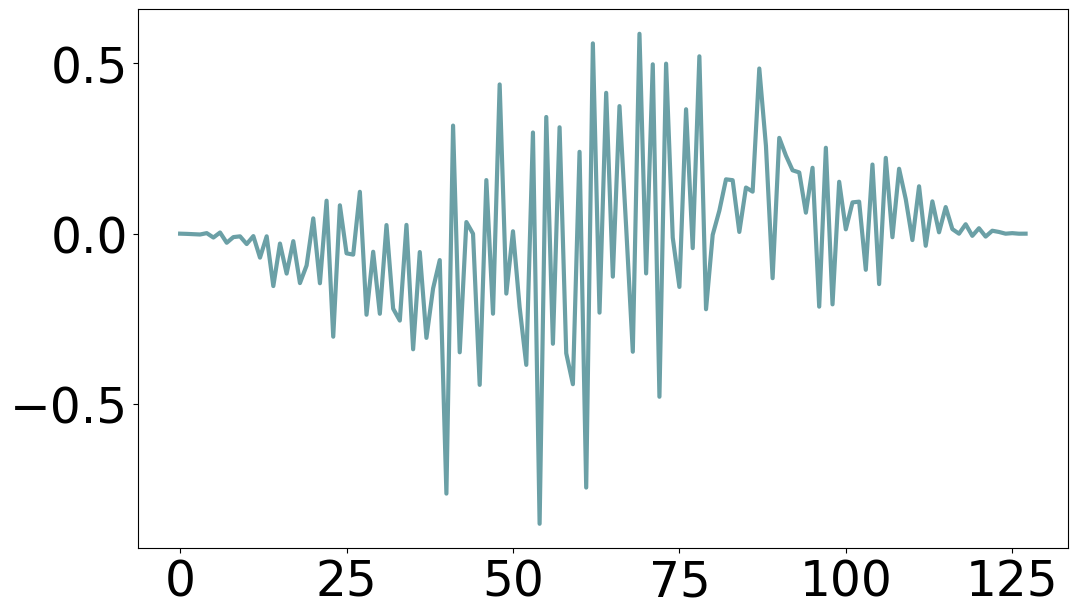

In [ ]:
plt.plot(doppler_signal[0, :, 0])

In [ ]:
doppler_signal = np.swapaxes(doppler_signal, 0, -1)
doppler_signal = np.swapaxes(doppler_signal, 1, -1)

print(doppler_signal.shape)
doppler_signal = doppler_signal.reshape((doppler_signal.shape[0], -1))

(5, 47, 128)


In [ ]:
n_units_doppler = 1
t_max = Param.T * fmcw.n_chirps
res_net_doppler = AdaptiveResonate(
            n_units_doppler, 
            t_max, 
            Param.T, 
            k=1,
            feedback=True,
            w_scale= np.ones((doppler_signal.shape[0], n_units_doppler))*Param.T*10*3,
            n_rxs=doppler_signal.shape[0]
)

# res_net.spike_condition = res_net.period_spiking
res_net_doppler.normalize_input = False
res_net_doppler.normalize_neuron = True

res_net_doppler.wdot_mode = False

res_net_doppler.spike_threshold = 0.05 / Param.dr

min_starting_freq = 2
max_starting_freq = 30

res_net_doppler.set_starting_frequency((np.linspace(0.0, 2.5, n_units_doppler) / Param.dr) * 2 * np.pi)
    
res_net_doppler.periods = ((2 * np.pi) / (res_net_doppler.ws * res_net_doppler.t_res)).astype(int)

/tmp/ipykernel_185275/431174002.py:26: RuntimeWarning: divide by zero encountered in divide
  res_net_doppler.periods = ((2 * np.pi) / (res_net_doppler.ws * res_net_doppler.t_res)).astype(int)
/tmp/ipykernel_185275/431174002.py:26: RuntimeWarning: invalid value encountered in cast
  res_net_doppler.periods = ((2 * np.pi) / (res_net_doppler.ws * res_net_doppler.t_res)).astype(int)


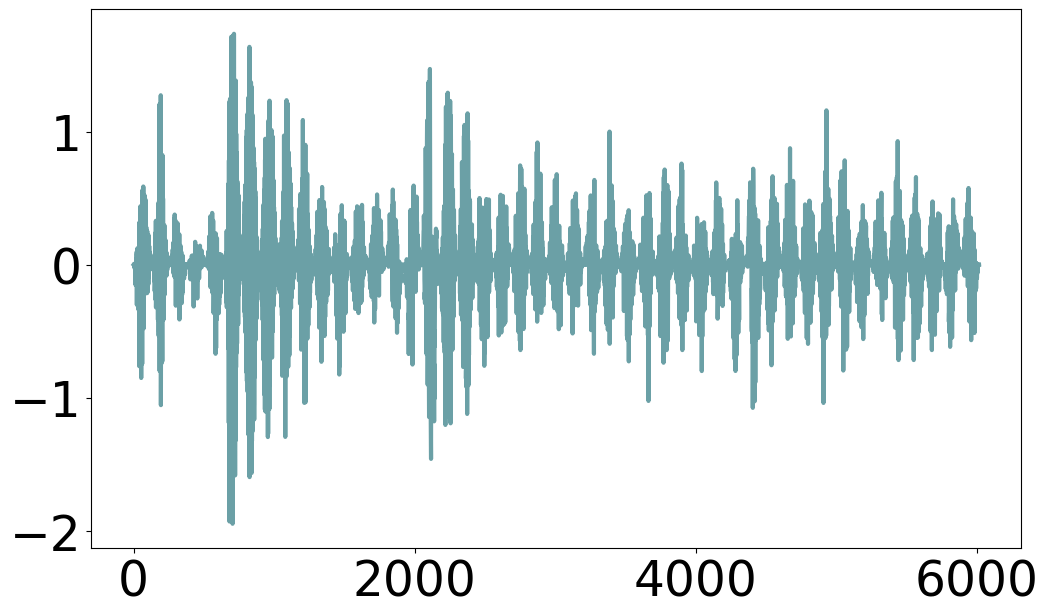

In [ ]:
plt.plot(doppler_signal.real[0])

In [ ]:
freqs = np.fft.fftfreq(Param.ntt_azimuth, Param.T)
vels = ((FmcwRadar.c / Param.f0) * freqs) / 2

In [ ]:
doppler_fft = np.fft.fft(doppler_signal[0,:128].squeeze())
doppler_fft = np.fft.fftshift(doppler_fft)

In [ ]:
argmax = np.argsort(np.abs(doppler_fft))[-5:]
argmax
peaks = vels[argmax]
peaks

array([-0.13269639, -0.09952229, -0.16587049, -1.04498408, -0.14928344])

In [ ]:
vs_hist_doppler, ws_hist_doppler = res_net_doppler.update_neurons_c(doppler_signal)
# ws_hist_doppler = -ws_hist_doppler


In [ ]:
vel_hist = Param.dr * (ws_hist_doppler / (2 * np.pi))

In [ ]:
vel_hist = np.mod(vel_hist + vels.max(), vels.max() * 2) - vels.max()
peaks = np.mod(peaks + vels.max(), vels.max() * 2) - vels.max()

In [ ]:
vel_hist_plot = -vel_hist
ranges = range_hist[-1]
velocities = vel_hist_plot[-1]
ranges = np.tile(ranges.squeeze(), (n_units_doppler, 1)).T.flatten()

In [ ]:
full_ranges = fmcw.get_ranges2()

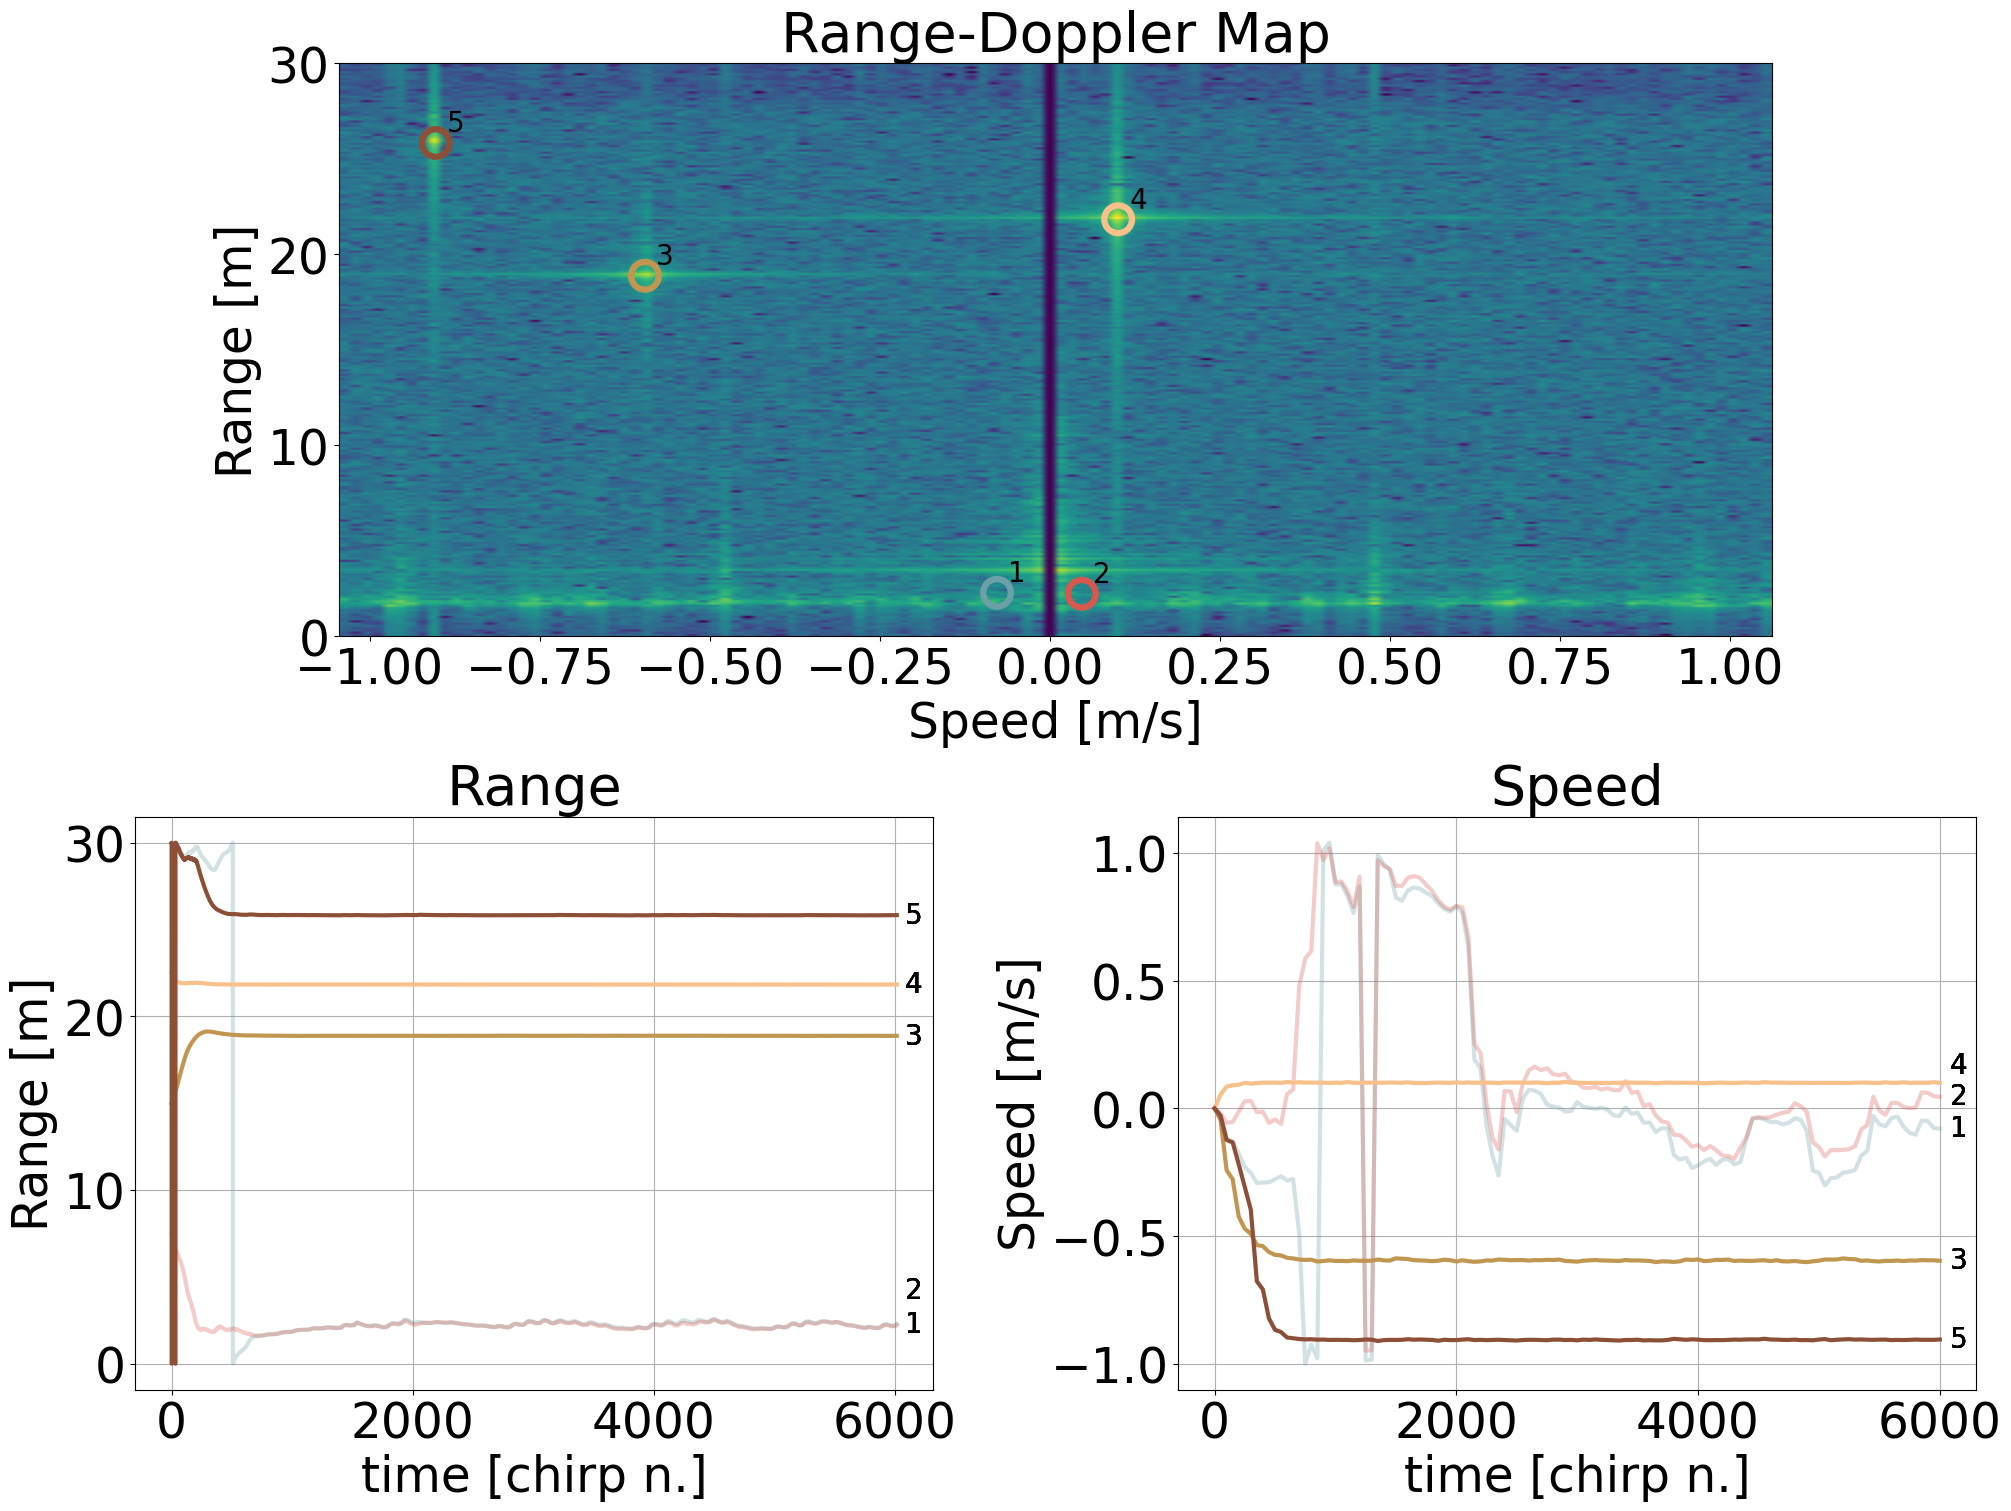

In [ ]:
fig = plt.figure(layout="constrained", figsize=(20,  15))

gs = GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, :])
ax1.set_box_aspect(0.4)

ax2 = fig.add_subplot(gs[1, :-1])
ax3 = fig.add_subplot(gs[1, -1])
# ax4 = fig.add_subplot(gs[2, :])

fft2 = np.fft.fft2(data_full[-1].T)
fft2 = np.fft.fftshift(fft2, axes=1)
# fft2 = np.fft.fftshift(fft2, axes=0)
fft_db = 20*np.log10(np.abs(fft2))
vels_plot = np.fft.fftshift(vels)
c = ax1.imshow(fft_db, 
               aspect='auto',
               origin="lower", 
               extent=[
                        -vels_plot[0],
                        -vels_plot[-1],
                        full_ranges[0],
                        full_ranges[-1]],
               vmin=40.0)
# plt.colorbar(c, ax=ax1)

colors = [f"C{i}" for i in range(ranges.size)]
facecolors = ["none" for i in range(ranges.size)]

ax1.scatter(velocities, ranges, 
            edgecolors=colors, 
            facecolors=facecolors, 
            s=20, 
            linewidths=20)
fig.canvas.draw()
for i, (v,r) in enumerate(zip(-velocities, ranges)):
    # convert to axes cooddinate for more consistent shifting
    x_text_position, y_text_position = ax1.transAxes.inverted().transform(
                                            ax1.transData.transform((v[0], r)))
    # shift them to the side of the circles
    # x_text_position += 0.02
    y_text_position += 0.02
    # draw
    ax1.text(x_text_position, y_text_position, f"{i+1}", 
             fontsize=20, transform=ax1.transAxes)

def print_labels(ax, x_position, y_positions):
    y_text_positions_range = []

    for i in range(len(y_positions)):
        x_text_position, y_text_position = ax.transAxes.inverted().transform(
                                            ax.transData.transform((x_position, y_positions[i])))
        # print(y_text_position)
        x_text_position += 0.01
        # y_text_position += 0.01
        if len(y_text_positions_range) == 0:
            ax.text(x_text_position, y_text_position, 
                    f"{i+1}", fontsize=20, transform=ax.transAxes, verticalalignment='center')
            y_text_positions_range.append(y_text_position)
        else:
            while(np.min(np.abs(y_text_position - y_text_positions_range)) < 0.03):
                y_text_position += 0.03
            ax.text(x_text_position, y_text_position, 
                    f"{i+1}", fontsize=20, transform=ax.transAxes, verticalalignment='center')
            y_text_positions_range.append(y_text_position)

total_chirps = data_full.shape[0] * data_full.shape[1]
range_time = np.linspace(0, total_chirps, range_hist.shape[0])
vel_time = np.linspace(0, total_chirps, vel_hist_plot.shape[0])

for i in range(n_units_range):
    ax2.plot(range_time[::50], range_hist.reshape(range_hist.shape[0], -1)[::50, i], 
             alpha=1 if ranges[i] > 5 else 0.3)
    # print_labels(ax2, range_time[::50][-1] - 1000, range_hist.reshape(range_hist.shape[0], -1)[-1, :])

for i in range(n_units_range):
    ax3.plot(vel_time[::50], vel_hist_plot.reshape(vel_hist_plot.shape[0], -1)[::50, i], 
             alpha=1 if ranges[i] > 5 else 0.3)
fig.canvas.draw()
# ax4.plot(np.abs(vs_hist_doppler[-1000:].squeeze()))
for i in range(n_units_range):
    print_labels(ax2, range_time[::50][-1], range_hist.reshape(range_hist.shape[0], -1)[-1, :])
    print_labels(ax3, vel_time[-1], vel_hist_plot.reshape(vel_hist_plot.shape[0], -1)[-1, :])

ax2.grid()
ax3.grid()

ax1.set_title("Range-Doppler Map")
ax2.set_title("Range")
ax3.set_title("Speed")

ax1.set_xlabel("Speed [m/s]")
ax1.set_ylabel("Range [m]")

ax2.set_xlabel("time [chirp n.]")
ax2.set_ylabel("Range [m]")

ax3.set_xlabel("time [chirp n.]")
ax3.set_ylabel("Speed [m/s]")

ax1.invert_xaxis()

plt.savefig("../paper_figures/range_doppler_real_data_3targets.pdf", bbox_inches='tight')

In [ ]:
mask = ranges > 5
ranges[mask]

array([18.87860499, 21.83506704, 25.83048642])

In [ ]:
velocities[mask]

array([[-0.59559144],
       [ 0.10018629],
       [-0.90333394]])

In [ ]:
range_spikes = np.abs(res_net_doppler.spikes_out).sum()

In [ ]:
integrated_doppler = res_net_doppler.integrate_spikes()
integrated_doppler = integrated_doppler.reshape((integrated_doppler.shape[0], -1))

In [ ]:
doppler_spikes = np.abs(res_net.spikes_out).sum()

In [ ]:
integrated = res_net.integrate_spikes()
integrated = integrated.reshape((integrated.shape[0], -1))

In [ ]:
ranges_int = fmcw.get_range_from_freq(integrated / (2 * np.pi))
velocities_int = Param.dr * (integrated_doppler / (2 * np.pi))

In [ ]:
velocities_int = np.mod(velocities_int + vels.max(), vels.max() * 2) - vels.max()

In [ ]:
def plot_single_neuron_raster(ax, spikes_out, color):
    
    total_steps = spikes_out.size
    range_spikes_pos = np.nonzero(spikes_out > 0)[0]
    range_spikes_pos = range_spikes_pos / total_steps
    range_spikes_pos *= data_full.shape[0] * data_full.shape[1]

    range_spikes_neg = np.nonzero(spikes_out < 0)[0]
    range_spikes_neg = range_spikes_neg / total_steps
    range_spikes_neg *= data_full.shape[0] * data_full.shape[1]

    for sp in range_spikes_pos:
        ax.axvline(sp, ymin=0.5, ymax=0.95, c=color)
    for sn in range_spikes_neg:
        ax.axvline(sn, ymin=0.05, ymax=0.48, c=color)

    ax.axhline(0, c='grey', linewidth=2, linestyle=':')
    ax.set_ylim([-1, 1])
    # Hide the right and top spines
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

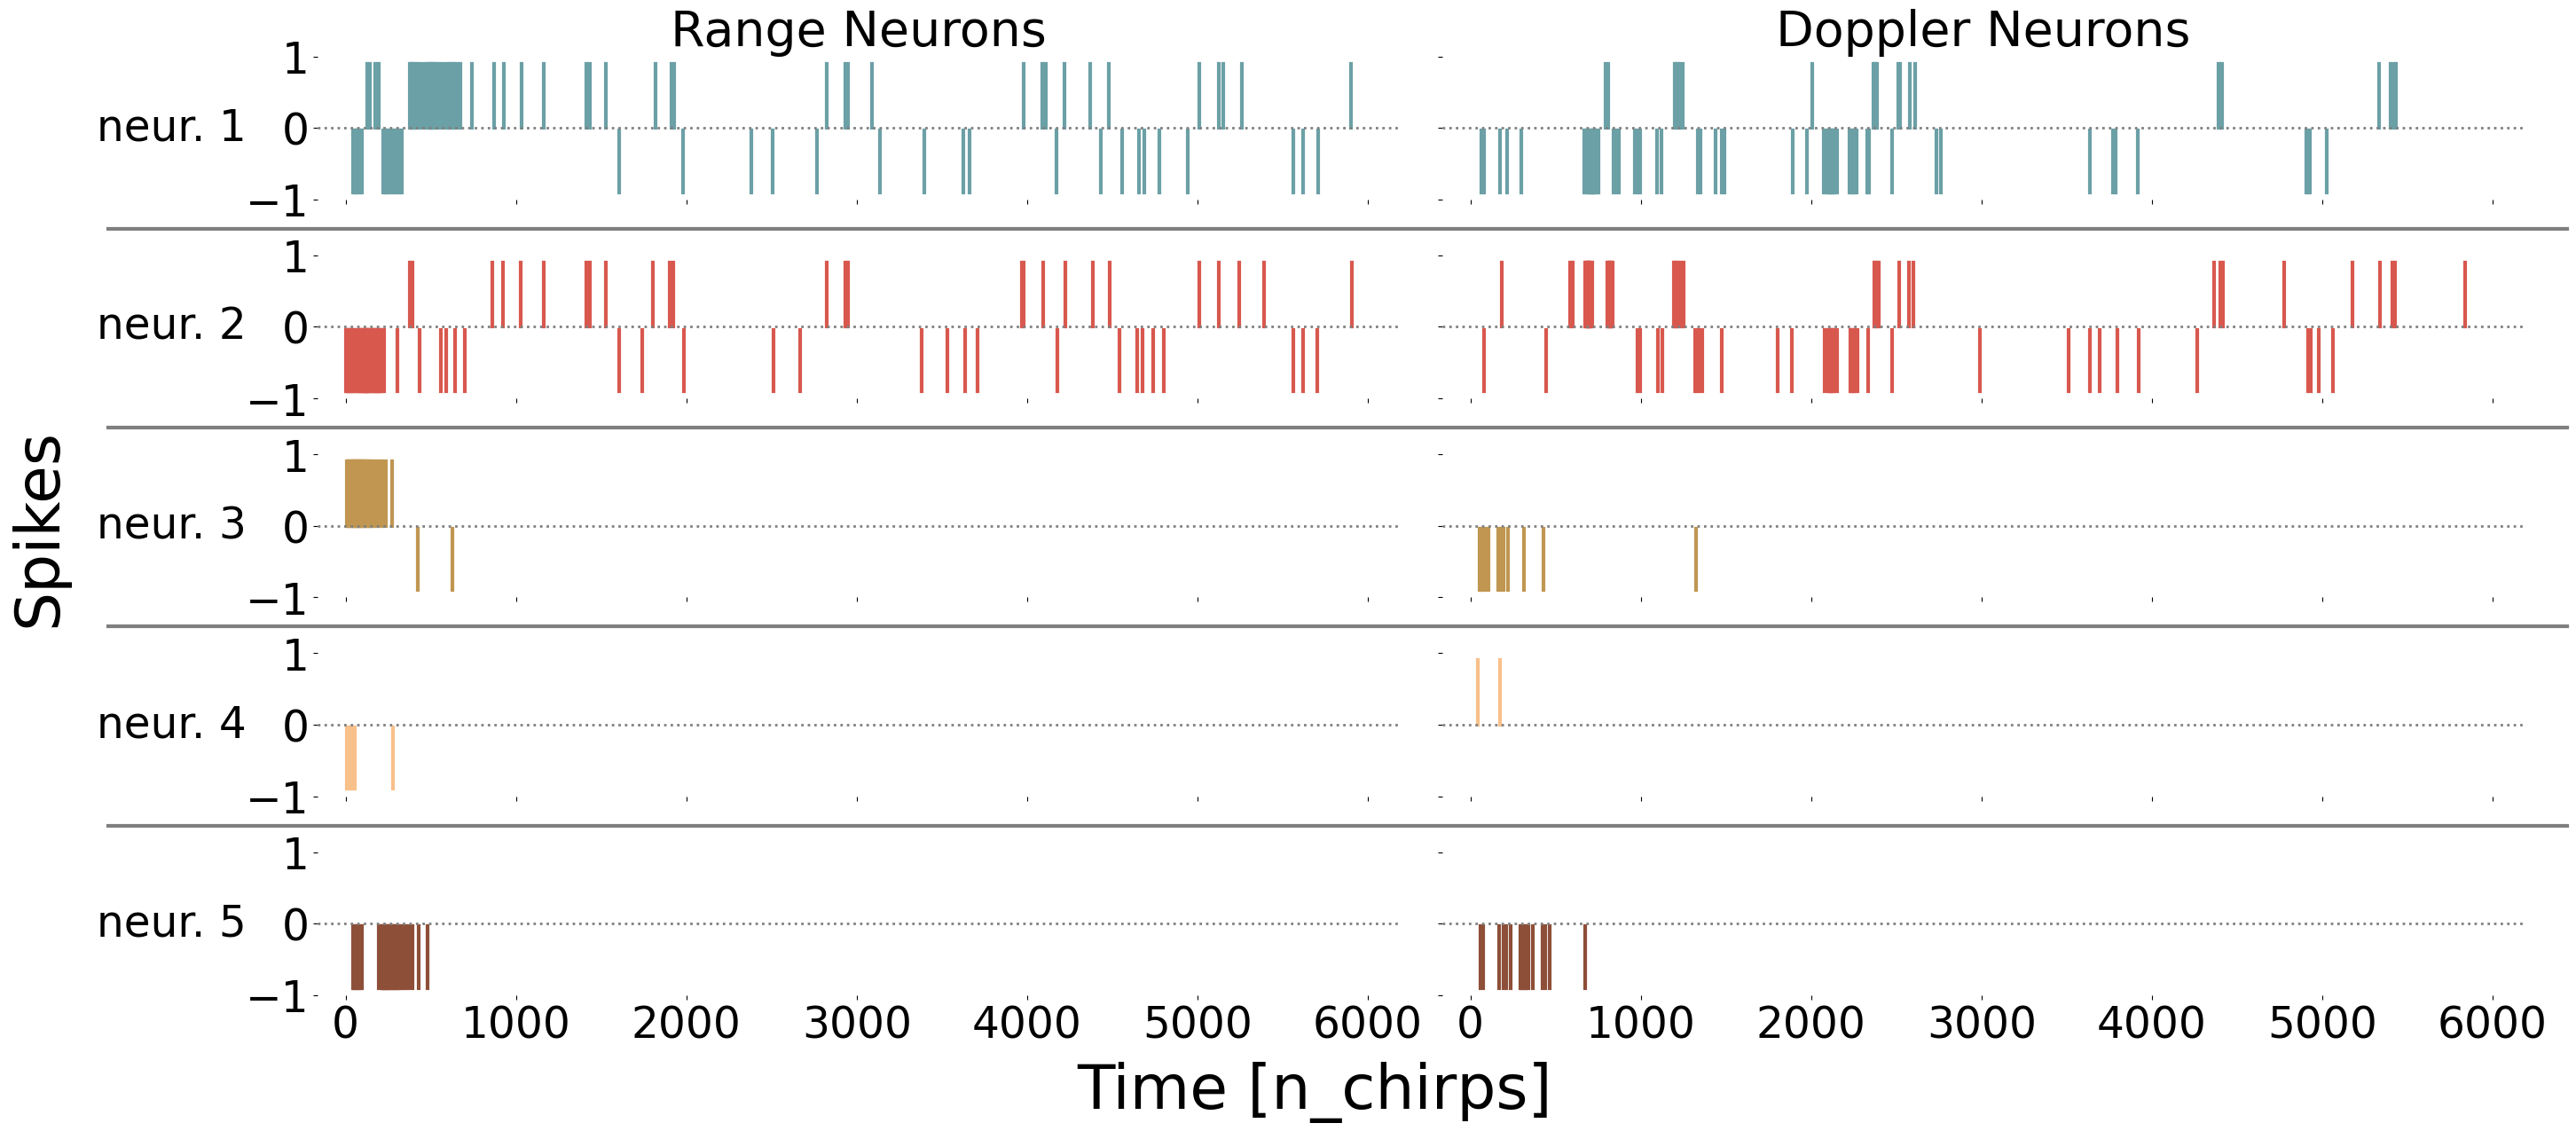

In [ ]:
import matplotlib.transforms as mtrans

fig, axs = plt.subplots(
    nrows=n_units_range,
    ncols=2,
    sharex=True,
    sharey=True,
    figsize=(28, 12)
)

for i in range(n_units_range):
    plot_single_neuron_raster(axs[i, 0], res_net.spikes_out.squeeze()[:, i], color=f"C{i}")
    axs[i, 0].set_ylabel(f"neur. {i+1}", rotation='horizontal', labelpad=60, va='center')

for i in range(n_units_range):
    # we flipped the sign of all the result, both FFT and ARF
    # something must be weird with the parameters
    plot_single_neuron_raster(axs[i, 1], -res_net_doppler.spikes_out.squeeze()[:, i], color=f"C{i}")

axs[0, 0].set_title("Range Neurons")
axs[0, 1].set_title("Doppler Neurons")

fig.text(-0.03, 0.5, 'Spikes', va='center', rotation='vertical', fontsize=50)
fig.text(0.4, -0.03, 'Time [n_chirps]', va='center', fontsize=50)

plt.tight_layout()

for i in range(1, n_units_range):

    y = axs[i, 0].get_position().y1 + 0.025

    line = plt.Line2D(
        [0.01, 1.0],
        [y, y],
        transform=fig.transFigure,
        color='black',
        linewidth=3,
        linestyle='-',
        alpha=0.5
    )

    fig.add_artist(line)

plt.savefig("../paper_figures/real_data_spike_raster.pdf", bbox_inches='tight')


Detected Targets:
------------------------------------------------------------
Target 1: Range = 21.88 m | Velocity = -0.10 m/s | Magnitude = 4230077.54
Target 2: Range = 25.88 m | Velocity = 0.91 m/s | Magnitude = 1730522.16
Target 3: Range = 18.94 m | Velocity = 0.60 m/s | Magnitude = 1159221.48
Target 4: Range = 1.65 m | Velocity = -0.48 m/s | Magnitude = 1103183.47
Target 5: Range = 3.41 m | Velocity = -0.02 m/s | Magnitude = 1048580.82
Target 6: Range = 3.41 m | Velocity = 0.02 m/s | Magnitude = 551606.84
Target 7: Range = 1.65 m | Velocity = -0.68 m/s | Magnitude = 533115.71
Target 8: Range = 1.65 m | Velocity = 0.68 m/s | Magnitude = 487156.60
Target 9: Range = 1.88 m | Velocity = -0.48 m/s | Magnitude = 444677.73
Target 10: Range = 1.88 m | Velocity = 0.48 m/s | Magnitude = 326012.05
Target 11: Range = 1.53 m | Velocity = -0.96 m/s | Magnitude = 288389.10
Target 12: Range = 1.65 m | Velocity = -0.45 m/s | Magnitude = 252369.78
Target 13: Range = 1.76 m | Velocity = -0.96 m/s |

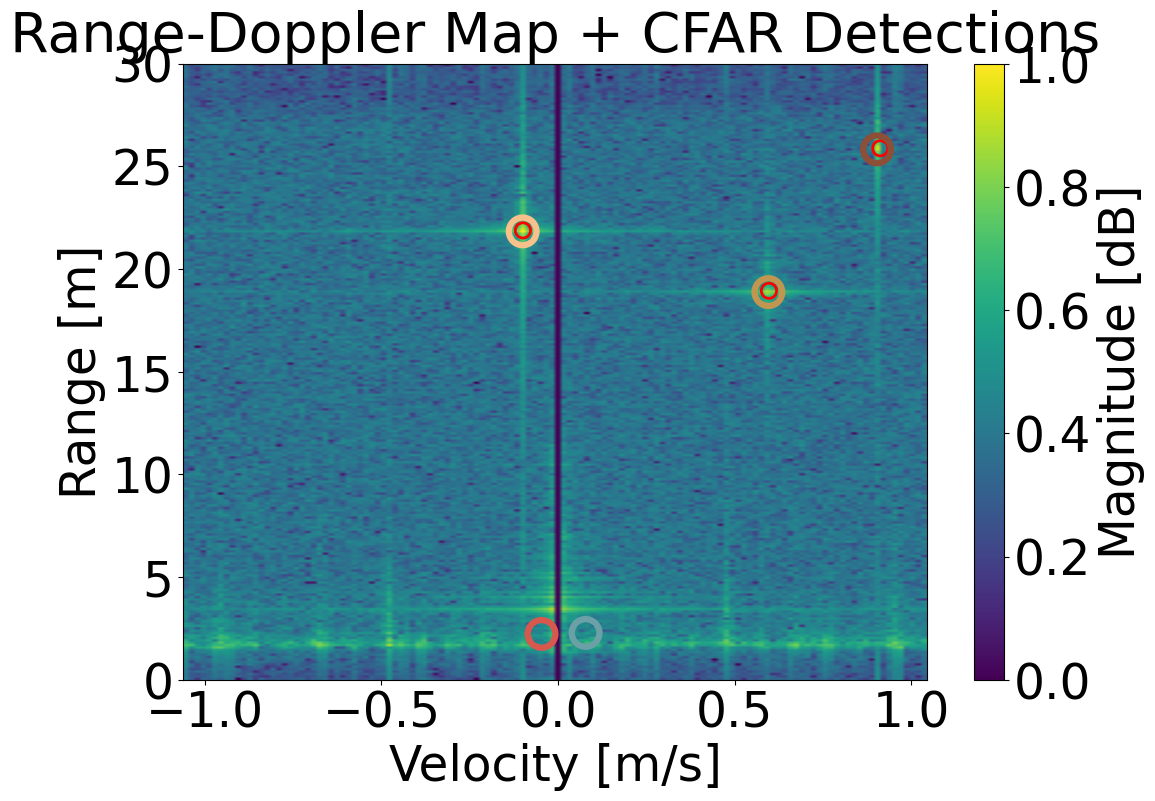

In [ ]:
rd_map = fft2

# Range axis
ranges_plot = fmcw.get_ranges2()

# Doppler axis
cels = np.fft.fftshift(vels) #fmcw.get_cels()

targets, peak_mask, threshold_map = utils.extract_targets(
    rd_map,
    ranges_plot,
    cels,
    guard_r=2,
    guard_d=2,
    train_r=8,
    train_d=4,
    pfa=1e-6,
)

print("\nDetected Targets:")
print("-" * 60)

for i, t in enumerate(targets):

    print(
        f"Target {i+1}: "
        f"Range = {t['range_m']:.2f} m | "
        f"Velocity = {t['velocity_m_s']:.2f} m/s | "
        f"Magnitude = {t['magnitude']:.2f}"
    )

# ============================================================
# Visualization
# ============================================================

plt.figure(figsize=(12, 8))

rd_db = 20 * np.log10(np.abs(rd_map) + 1e-12)

plt.imshow(
    rd_db,
    aspect='auto',
    origin='lower',
    extent=[
        cels[0],
        cels[-1],
        ranges_plot[0],
        ranges_plot[-1],
    ],
    vmin=40
)

plt.xlabel("Velocity [m/s]")
plt.ylabel("Range [m]")
plt.title("Range-Doppler Map + CFAR Detections")

# Overlay detections
order = np.argsort([t['magnitude'] for t in targets])[-3:]
targets_filtered = np.array(targets)[order]

for t in targets_filtered:

    plt.scatter(
        t["velocity_m_s"],
        t["range_m"],
        s=120,
        facecolors='none',
        edgecolors='r',
        linewidths=2,
    )

plt.scatter(-velocities, ranges, 
            edgecolors=colors, 
            facecolors=facecolors, 
            s=20, 
            linewidths=20)

plt.colorbar(label="Magnitude [dB]")
plt.show()

In [ ]:
gt_ranges = np.array([18.0, 21.0, 25.0])
gt_velocities = np.array([-0.6, 0.1, -0.9])

In [ ]:
mask = ranges > 5
measured_ranges = ranges[mask]
measured_velocities = velocities[mask].squeeze()

In [ ]:
order = np.argsort(measured_ranges)
measured_ranges = measured_ranges[order]
measured_velocities = measured_velocities[order]

In [ ]:
print(f"ground truth ranges: {gt_ranges}")
print(f"masured ranges: {measured_ranges}")
error_range = np.sqrt(np.square(gt_ranges - measured_ranges).mean())
print(f"RMSE: {error_range}")

ground truth ranges: [18. 21. 25.]
masured ranges: [18.87860499 21.83506704 25.83048642]
RMSE: 0.8483300044123411


In [ ]:
print(f"ground truth velocities: {gt_velocities}")
print(f"masured velocities: {measured_velocities}")
error_velocities = np.sqrt(np.square(gt_velocities - measured_velocities).mean())
print(f"RMSE: {error_velocities}")

ground truth velocities: [-0.6  0.1 -0.9]
masured velocities: [-0.59559144  0.10018629 -0.90333394]
RMSE: 0.0031929742719500162


In [ ]:
targets_filtered_fft = targets_filtered

In [ ]:
fft_ranges = np.array([t['range_m'] for t in targets_filtered_fft])
fft_velocities = np.array([-t['velocity_m_s'] for t in targets_filtered_fft])
# we have to take the negative of the velocity for some reason

In [ ]:
order_fft = np.argsort(fft_ranges)
fft_ranges = fft_ranges[order_fft]
fft_velocities = fft_velocities[order_fft]

In [ ]:
print(f"ground truth ranges: {gt_ranges}")
print(f"masured ranges: {fft_ranges}")
error_range_fft = np.sqrt(np.square(gt_ranges - fft_ranges).mean())
print(f"RMSE: {error_range_fft}")

ground truth ranges: [18. 21. 25.]
masured ranges: [18.94117647 21.88235294 25.88235294]
RMSE: 0.9023869410983381


In [ ]:
print(f"ground truth velocities: {gt_velocities}")
print(f"masured velocities: {fft_velocities}")
error_velocities_fft = np.sqrt(np.square(gt_velocities - fft_velocities).mean())
print(f"RMSE: {error_velocities_fft}")

ground truth velocities: [-0.6  0.1 -0.9]
masured velocities: [-0.59713376  0.09952229 -0.91228769]
RMSE: 0.00728996500013102
